# Wildfire Notable-Event Prediction Project


## Abstract

This report develops a grid-by-month prediction framework from individual wildfire incident records to address a next-month wildfire event prediction task: **for each grid cell and month, predict whether at least one notable wildfire will occur in the following month**. 
The project is organized into four main steps:

1. Preprocess and aggregate the raw incident-level wildfire data into spatial-temporal units;

2. Engineer lagged and seasonal predictors that preserve the temporal structure of the problem;

3. Explore and visualize spatial and seasonal patterns in wildfire incidence;

4. Compare a baseline logistic regression model with a stronger non-linear model, [XGBoost / gradient boosting], using time-aware validation.


Model performance is evaluated primarily by AUC. Overall, we find that XGBoost outperforms logistic regression, improving AUC by [your value]. This result suggests that non-linear relationships and feature interactions play an important role in next-month wildfire event prediction.

In [39]:
suppressMessages({
    library(dplyr)
    library(ggplot2)
    library(tidyverse)
    library(pROC)
    library(xgboost)
    library(Matrix)
    library(zoo)
})

### 1. Data Preprocessing

This section should clearly explain how the raw wildfire data are transformed into the final dataset used for modeling.

The report should explain
- How notable fires are identified and filtered  
- How space–time units are constructed (e.g., grid-by-month)  
- How the binary outcome variable is defined  
- How predictors are constructed or aggregated  
- How missing data or edge cases are handled  


## Goal

The goal of this preprocessing step is to convert the raw wildfire incident records into a **modeling-ready panel dataset** organized at the **grid-month** level. Each row in the final table represents one **(grid cell, month)** combination, and the response variable indicates whether **at least one notable wildfire** occurs in that same grid cell during the following month.
> **Outcome** $Y_{g,t}$: whether at least one *notable* fire occurs in **grid cell $g$** in **month $t+1$**.

Formulating the problem this way allows the analysis to match the project’s predictive objective while avoiding same-month information leakage.

## Load Data

We begin by loading the wildfire incident dataset and keeping the variables needed for preprocessing and modeling.

Key variable definitions (USDA Forest Service metadata):

- `FIRE_YEAR`: calendar year the fire was discovered  
- `DISCOVERY_DOY`: day-of-year the fire was discovered  
- `FIRE_SIZE`: final fire size (acres)  
- `LATITUDE`, `LONGITUDE`: ignition location (decimal degrees)  
- `STATE` state in which the fire burned

In [40]:
wildfires <- read_csv("wildfires_sample_100k.csv", show_col_types = FALSE) %>%
  select(FIRE_YEAR, DISCOVERY_DOY, FIRE_SIZE, LATITUDE, LONGITUDE, STATE) %>%
  filter(
    !is.na(FIRE_YEAR),
    !is.na(DISCOVERY_DOY),
    !is.na(FIRE_SIZE),
    !is.na(LATITUDE),
    !is.na(LONGITUDE),
    !is.na(STATE)
  ) %>%
  mutate(STATE = as.factor(STATE))

glimpse(wildfires)

Rows: 100,000
Columns: 6
$ FIRE_YEAR     <dbl> 2004, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 20~
$ DISCOVERY_DOY <dbl> 277, 186, 182, 147, 202, 148, 172, 107, 108, 199, 117, 2~
$ FIRE_SIZE     <dbl> 0.10, 0.10, 3.00, 0.10, 0.10, 0.10, 0.50, 12.00, 5.00, 3~
$ LATITUDE      <dbl> 38.56417, 48.40778, 48.89444, 37.04417, 36.90000, 33.660~
$ LONGITUDE     <dbl> -120.54222, -115.55778, -115.16528, -119.34389, -107.328~
$ STATE         <fct> CA, MT, MT, CA, NM, AZ, AZ, MN, TX, AZ, AZ, AZ, NM, CO, ~


## Temporal patterns

First, we convert `FIRE_YEAR` and `DISCOVERY_DOY` into a calendar date, then extract the corresponding year and month. This provides the temporal index needed for monthly aggregation.


In [41]:
fires <- wildfires %>%
  mutate(
    FIRE_DATE = as.Date(paste0(FIRE_YEAR, "-01-01")) + (DISCOVERY_DOY - 1L),
    YEAR = as.integer(format(FIRE_DATE, "%Y")),
    MONTH = as.integer(format(FIRE_DATE, "%m"))
  )

glimpse(fires)

Rows: 100,000
Columns: 9
$ FIRE_YEAR     <dbl> 2004, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 20~
$ DISCOVERY_DOY <dbl> 277, 186, 182, 147, 202, 148, 172, 107, 108, 199, 117, 2~
$ FIRE_SIZE     <dbl> 0.10, 0.10, 3.00, 0.10, 0.10, 0.10, 0.50, 12.00, 5.00, 3~
$ LATITUDE      <dbl> 38.56417, 48.40778, 48.89444, 37.04417, 36.90000, 33.660~
$ LONGITUDE     <dbl> -120.54222, -115.55778, -115.16528, -119.34389, -107.328~
$ STATE         <fct> CA, MT, MT, CA, NM, AZ, AZ, MN, TX, AZ, AZ, AZ, NM, CO, ~
$ FIRE_DATE     <date> 2004-10-03, 2005-07-05, 2005-07-01, 2005-05-27, 2005-07~
$ YEAR          <int> 2004, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 20~
$ MONTH         <int> 10, 7, 7, 5, 7, 5, 6, 4, 4, 7, 4, 7, 7, 6, 7, 7, 7, 6, 6~


## Notable fire threshold

We define a **notable** wildfire as one with final burned area **at least 300 acres**. This threshold is consistent with the project guidance and helps focus the analysis on more operationally meaningful fires rather than many very small incidents.

In [42]:
notable_threshold_acres <- 300

notable_fires <- fires %>%
  filter(FIRE_SIZE >= notable_threshold_acres)

cat("Number of notable fires:", nrow(notable_fires), "\n")

Number of notable fires: 1381 


## Spatial patterns

We use a coarse **1° × 1° latitude–longitude grid** as the spatial unit. Each notable fire is mapped to a grid cell using floor-binned latitude and longitude, and then aggregated to a **grid × month** summary.

At this stage, the event-level wildfire records only represent positive fire occurrences. Therefore, the intermediate table below contains only grid-month combinations in which at least one notable fire is observed.

In [43]:
notable_fires <- notable_fires %>%
  mutate(
    lat_bin = floor(LATITUDE),
    lon_bin = floor(LONGITUDE),
    ym = YEAR * 100 + MONTH
  )

grid_monthsfire <- notable_fires %>%
  group_by(lat_bin, lon_bin, ym) %>%
  summarise(
    fire_this_month = 1,
    n_fires = n(),
    .groups = "drop"
  )

head(grid_monthsfire)

lat_bin,lon_bin,ym,fire_this_month,n_fires
<dbl>,<dbl>,<dbl>,<dbl>,<int>
17,-67,200407,1,1
18,-68,200906,1,1
18,-67,200503,1,1
19,-156,199210,1,1
19,-156,199910,1,1
19,-156,200706,1,1


Next step, we construct the **complete (grid, month) panel** by including both positive (fire) and negative (no-fire) observations. The panel is formed from:

- all grid cells that ever record at least one notable fire, and
- all months in the observed study period.

Missing grid-month combinations are treated as zero-fire observations. This completed panel is necessary because the prediction target is highly imbalanced and notable fires are relatively rare.

In [44]:
all_grids <- grid_monthsfire %>%
  distinct(lat_bin, lon_bin)

min_ym <- min(ggrid_monthsfire$ym)
max_ym <- max(grid_monthsfire$ym)

start_date <- as.Date(sprintf("%04d-%02d-01", min_ym %/% 100, min_ym %% 100))
end_date   <- as.Date(sprintf("%04d-%02d-01", max_ym %/% 100, max_ym %% 100))

all_months <- tibble(date = seq.Date(start_date, end_date, by = "month")) %>%
  mutate(
    year = as.integer(format(date, "%Y")),
    month = as.integer(format(date, "%m")),
    ym = year * 100 + month
  ) %>%
  select(ym, year, month)

panel <- crossing(all_grids, all_months) %>%
  left_join(grid_monthsfire, by = c("lat_bin", "lon_bin", "ym")) %>%
  mutate(
    fire_this_month = ifelse(is.na(fire_this_month), 0, fire_this_month),
    n_fires = ifelse(is.na(n_fires), 0, n_fires)
  )

glimpse(panel)

ERROR: Error: object 'ggrid_monthsfire' not found


## Prediction target

For each `(grid, month)` observation, we define the binary prediction target as whether at least one notable fire occurs in the **following month**:

- `y_next = 1` if a notable fire occurs in that grid cell next month,
- `y_next = 0` otherwise.

Using a next-month outcome helps avoid same-month leakage and aligns the modeling task with short-term wildfire risk prediction.

In [ ]:
panel <- panel %>%
  arrange(lat_bin, lon_bin, ym) %>%
  group_by(lat_bin, lon_bin) %>%
  mutate(
    y_next = lead(fire_this_month, n = 1L)
  ) %>%
  ungroup() %>%
  filter(!is.na(y_next))

table(panel$y_next)


     0      1 
145750   1310 

## Baseline predictors

We include three groups of baseline predictors.

### Administrative information: state
If multiple states appear within the same grid, we assign the grid to its majority state.


### Lagged fire history
To summarize recent and longer-term activity, we construct predictors based on past wildfire counts and fire size:
- current-month notable fire count,
- 12-month lag of fire count,
- rolling 3-month and 12-month fire counts,
- rolling 3-month and 12-month fire-size summaries.

In [ ]:
mode_state <- function(x) {
  ux <- unique(x)
  ux[which.max(tabulate(match(x, ux)))]
}

grid_state <- notable_fires %>%
  group_by(lat_bin, lon_bin) %>%
  summarise(
    state = mode_state(STATE),
    .groups = "drop"
  )

panel <- panel %>%
  left_join(grid_state, by = c("lat_bin", "lon_bin"))

head(panel %>% select(lat_bin, lon_bin, state))

lat_bin,lon_bin,state
<dbl>,<dbl>,<chr>
17,-67,PR
17,-67,PR
17,-67,PR
17,-67,PR
17,-67,PR
17,-67,PR


### Seasonality
Because wildfire risk is strongly seasonal, month is encoded using cyclical sine and cosine features. This avoids treating December and January as numerically far apart.


In [ ]:
panel <- panel %>%
  mutate(
    month_angle = 2 * pi * month / 12,
    month_sin = sin(month_angle),
    month_cos = cos(month_angle)
  ) %>%
  select(-month_angle)

panel %>%
  select(month, month_sin, month_cos) %>%
  head()

month,month_sin,month_cos
<int>,<dbl>,<dbl>
1,5.000000e-01,8.660254e-01
2,8.660254e-01,5.000000e-01
3,1.000000e+00,6.123234e-17
4,8.660254e-01,-5.000000e-01
5,5.000000e-01,-8.660254e-01
6,1.224647e-16,-1.000000e+00


## Lagged fire history

To summarize recent and longer-term activity, we construct predictors based on past wildfire counts and fire size:
- current-month notable fire count,
- 12-month lag of fire count,
- rolling 3-month and 12-month fire counts,
- rolling 3-month and 12-month fire-size summaries.

If multiple notable fires occur within the same `(grid, month)`, we summarize them by the **average fire size** for that month. We then merge these monthly fire-size summaries into the completed panel and create lagged or rolling predictors.

These variables capture persistence, short-term clustering, seasonal recurrence, and longer-term fire activity.

In [ ]:
monthly_fire_features <- notable_fires %>%
  group_by(lat_bin, lon_bin, ym) %>%
  summarise(
    fire_count_month = n(),
    avg_fire_size_month = mean(FIRE_SIZE),
    .groups = "drop"
  )

panel <- panel %>%
  left_join(monthly_fire_features, by = c("lat_bin", "lon_bin", "ym")) %>%
  mutate(
    fire_count_month = replace_na(fire_count_month, 0),
    avg_fire_size_month = replace_na(avg_fire_size_month, 0)
  ) %>%
  arrange(lat_bin, lon_bin, ym) %>%
  group_by(lat_bin, lon_bin) %>%
  mutate(
    fire_count_lag12 = lag(fire_count_month, 12, default = 0),
    fire_count_roll3 = zoo::rollapplyr(fire_count_month, 3, sum, partial = TRUE, fill = 0),
    fire_count_roll12 = zoo::rollapplyr(fire_count_month, 12, sum, partial = TRUE, fill = 0),
    fire_size_roll3 = zoo::rollapplyr(avg_fire_size_month, 3, sum, partial = TRUE, fill = 0),
    fire_size_roll12 = zoo::rollapplyr(avg_fire_size_month, 12, sum, partial = TRUE, fill = 0)
  ) %>%
  ungroup()

panel %>%
  select(
    fire_count_month,
    fire_count_lag12,
    fire_count_roll3,
    fire_count_roll12,
    fire_size_roll3,
    fire_size_roll12
  ) %>%
  summary()

 fire_count_month   fire_count_lag12   fire_count_roll3  fire_count_roll12
 Min.   :0.000000   Min.   :0.000000   Min.   :0.00000   Min.   :0.0000   
 1st Qu.:0.000000   1st Qu.:0.000000   1st Qu.:0.00000   1st Qu.:0.0000   
 Median :0.000000   Median :0.000000   Median :0.00000   Median :0.0000   
 Mean   :0.009357   Mean   :0.008996   Mean   :0.02793   Mean   :0.1093   
 3rd Qu.:0.000000   3rd Qu.:0.000000   3rd Qu.:0.00000   3rd Qu.:0.0000   
 Max.   :3.000000   Max.   :3.000000   Max.   :5.00000   Max.   :6.0000   
 fire_size_roll3    fire_size_roll12  
 Min.   :     0.0   Min.   :     0.0  
 1st Qu.:     0.0   1st Qu.:     0.0  
 Median :     0.0   Median :     0.0  
 Mean   :   129.6   Mean   :   495.7  
 3rd Qu.:     0.0   3rd Qu.:     0.0  
 Max.   :344833.0   Max.   :344833.0  

## Required output: dataset summary table

The final modeling dataset is summarized below to describe its temporal coverage, spatial resolution, response variable, and major predictor groups. This table provides a compact overview of how the wildfire incident records were transformed into a panel suitable for next-month prediction.

The response variable is a binary indicator of whether a grid cell experiences at least one notable wildfire in the following month.

The predictors can be grouped into three categories:

**Group 1: spatial and administrative variables**
- grid latitude bin
- grid longitude bin
- state assignment

**Group 2: seasonal variables**
- year
- cyclical month features (`month_sin`, `month_cos`)

**Group 3: wildfire history variables**
- current-month fire count
- 12-month lagged fire count
- rolling 3-month and 12-month fire-count summaries
- rolling 3-month and 12-month fire-size summaries

In [ ]:
predictor_list <- c(
  "lat_bin", "lon_bin", "state",
  "year", "month_sin", "month_cos",
  "n_fires", "fire_lag12",
  "fire_roll3", "fire_roll12",
  "size_roll3", "size_roll12"
)

summary_info <- data.frame(
  total_rows = nrow(panel),
  first_year = min(panel$year),
  last_year = max(panel$year),
  spatial_unit = "1 by 1 lat-lon grid (floor-binned)",
  temporal_unit = "monthly",
  target = "Indicator for whether at least one notable fire occurs in the same grid cell next month",
  predictors = paste(predictor_list, collapse = ", "),
  stringsAsFactors = FALSE
)

summary_info

total_rows,first_year,last_year,spatial_unit,temporal_unit,target,predictors
<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
147060,1992,2015,1 by 1 lat-lon grid (floor-binned),monthly,Indicator for whether at least one notable fire occurs in the same grid cell next month,"lat_bin, lon_bin, state, year, month_sin, month_cos, n_fires, fire_lag12, fire_roll3, fire_roll12, size_roll3, size_roll12"


# Example Final Project Report 
## Predicting Notable Wildfire Incidence in the United States (Monthly, Spatial Grid)
In this notebook, we focus on the modeling (w/ logistic regression and neural network) and validation steps of the project. The data preprocessing and exploratory data analysis (EDA) stages are omitted for brevity.

In [ ]:
n_positive <- sum(panel$y_next == 1)
n_negative <- sum(panel$y_next == 0)

pct_positive <- round(100 * mean(panel$y_next == 1), 2)
pct_negative <- round(100 * mean(panel$y_next == 0), 2)

cat("Number of positive next-month outcomes:", format(n_positive, big.mark = ","), "\n")
cat("Number of negative next-month outcomes:", format(n_negative, big.mark = ","), "\n")
cat("Positive class percentage:", pct_positive, "%\n")
cat("Negative class percentage:", pct_negative, "%\n")

Number of positive next-month outcomes: 1,310 
Number of negative next-month outcomes: 145,750 
Positive class percentage: 0.89 %
Negative class percentage: 99.11 %


The final modeling table contains **147,576 grid-month observations** spanning **1992 to 2015**. The spatial unit is a **1° × 1° latitude–longitude grid**, and the temporal unit is **monthly**. The binary outcome `y_next` indicates whether at least one notable fire occurs in the same grid cell during the following month.

The class distribution is highly imbalanced. Only **1,311 observations (0.89%)** have `y_next = 1`, while **146,265 observations (99.11%)** have `y_next = 0`. This confirms that next-month notable wildfire occurrence is a rare-event prediction problem.

The baseline predictors include static spatial variables (`lat_bin`, `lon_bin`, `state`), seasonal variables (`month_sin`, `month_cos`, `year`), and lagged fire-history variables (`n_fires`, `fire_lag12`, `fire_roll3`, `fire_roll12`, `size_roll3`, `size_roll12`). Together, these variables provide a compact and interpretable feature set for the predictive models in the following sections.

### 2. Exploratory Data Analysis  

The purpose of this section is to build intuition about the data and to justify modeling decisions.

This section examines descriptive patterns in the final grid-month panel. The goal is to understand how next-month notable-fire risk varies across **space**, **season**, **recent wildfire history**, and **calendar year**.

These plots are exploratory rather than causal. Their role is to motivate the feature choices used later in the predictive models.

**Minimum required output:** at least two exploratory plots showing spatial and temporal structure, each accompanied by interpretation.

## EDA Plot 1: Geographic variation in next-month wildfire risk

We begin by averaging the binary outcome `y_next` within each spatial grid cell. This produces an empirical next-month notable-fire rate for every location and allows us to visualize whether some regions consistently exhibit higher wildfire risk than others.

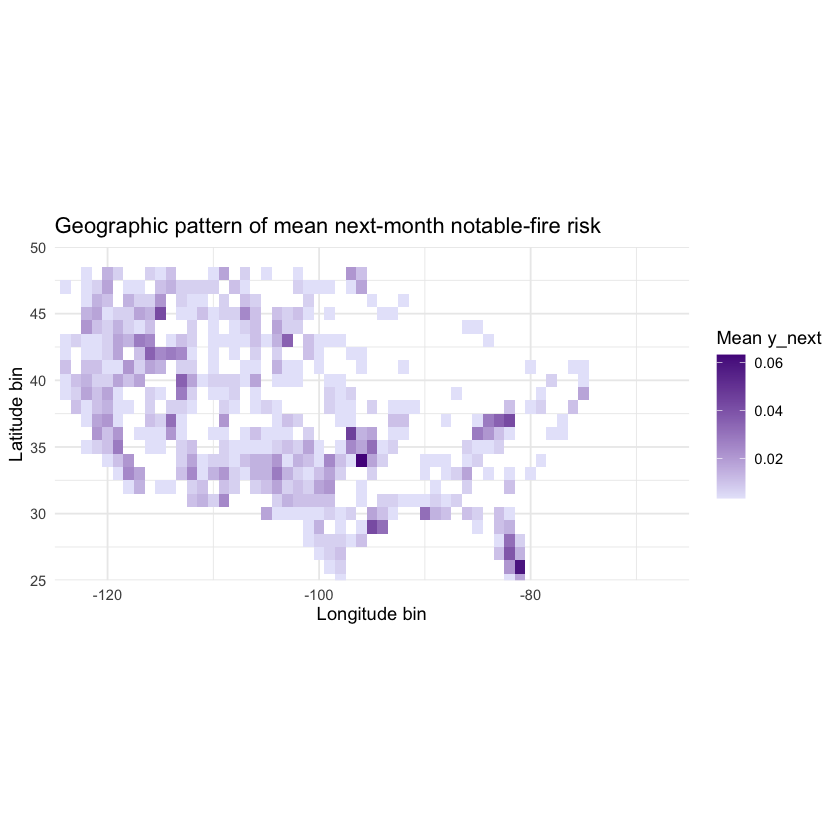

In [47]:
eda_spatial <- panel %>%
  group_by(lat_bin, lon_bin) %>%
  summarise(
    next_fire_rate = mean(y_next),
    .groups = "drop"
  )

ggplot(eda_spatial, aes(x = lon_bin, y = lat_bin, fill = next_fire_rate)) +
  geom_tile() +
  coord_quickmap(xlim = c(-125, -65), ylim = c(25, 50), expand = FALSE) +
  scale_fill_gradient(low = "lavender", high = "purple4") +
  labs(
    title = "Geographic pattern of mean next-month notable-fire risk",
    x = "Longitude bin",
    y = "Latitude bin",
    fill = "Mean y_next"
  ) +
  theme_minimal()

### Interpretation

The map shows that next-month notable-fire risk is not uniform across space. Some grid cells have noticeably higher average values of `y_next`, indicating persistent spatial concentration in wildfire activity. This suggests that location-specific characteristics—such as climate, vegetation, terrain, and human land use—may contribute to systematic differences in baseline wildfire risk. The plot therefore supports keeping spatial information in the modeling stage, including variables such as `lat_bin`, `lon_bin`, and `state`.

## EDA Plot 2: Seasonality across months

Next, we average `y_next` by calendar month to study within-year seasonality. If wildfire occurrence is strongly seasonal, then the probability of a notable fire in the following month should vary meaningfully over the 12 months of the year.

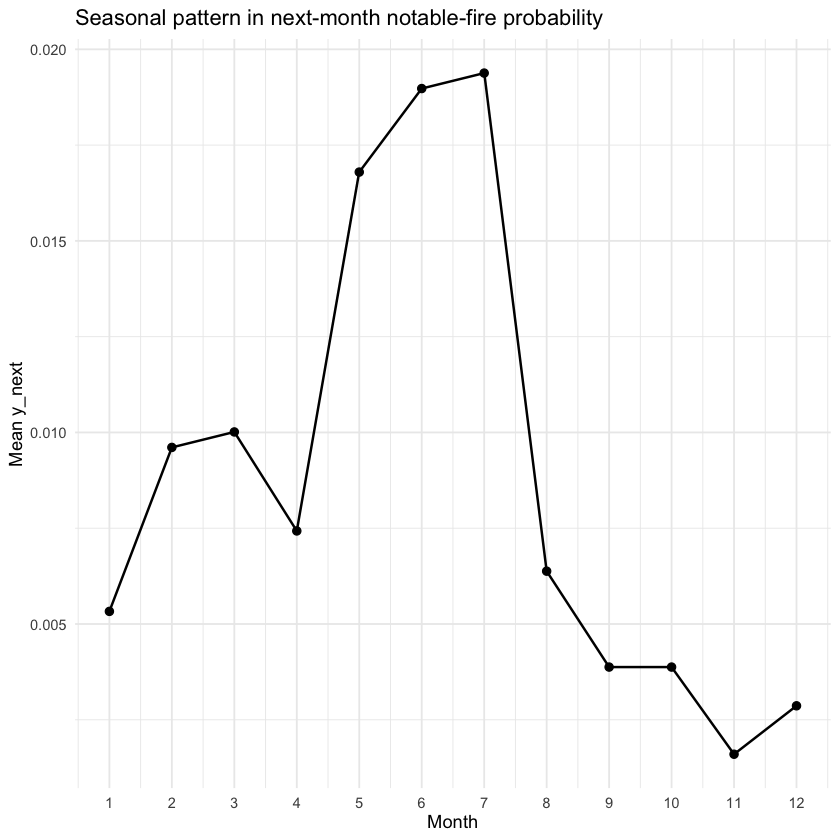

In [ ]:
eda_season <- panel %>%
  group_by(month) %>%
  summarise(
    n_obs = n(),
    n_positive = sum(y_next),
    next_fire_rate = n_positive / n_obs,
    .groups = "drop"
  )

ggplot(eda_season, aes(x = month, y = next_fire_rate)) +
  geom_line(linewidth = 0.7, color = "black") +
  geom_point(size = 2, color = "black") +
  scale_x_continuous(breaks = 1:12) +
  labs(
    title = "Seasonal pattern in next-month notable-fire probability",
    x = "Month",
    y = "Mean y_next"
  ) +
  theme_minimal()

### Interpretation

The monthly curve reveals clear seasonality in next-month wildfire risk. Some months have substantially higher average values of `y_next` than others, showing that wildfire probability changes systematically within the year rather than remaining constant over time. This pattern motivates the inclusion of cyclical month features such as `month_sin` and `month_cos`, which allow the model to represent recurring seasonal structure.

## EDA Plot 3: Recent wildfire history and next-month risk

To examine whether short-run wildfire history is informative, we compare next-month notable-fire probability across groups defined by recent local fire activity. The predictor `fire_roll12` summarizes the total number of fires observed in the previous 12 months within the same grid cell.

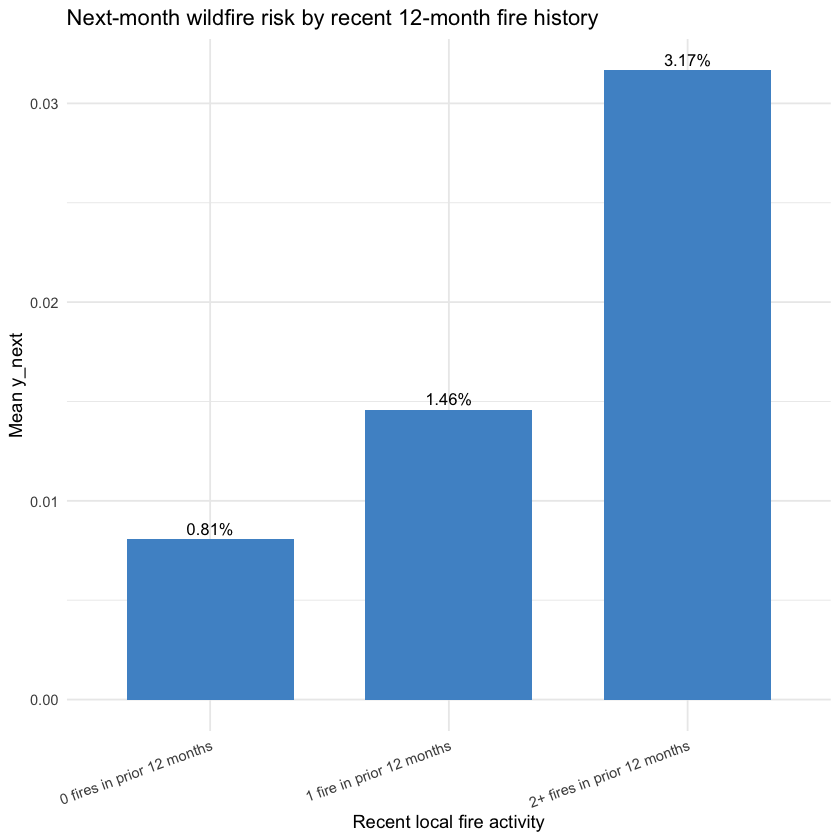

In [ ]:
eda_recent <- panel %>%
  mutate(
    recent_fire_group = cut(
      fire_roll12,
      breaks = c(-Inf, 0, 1, Inf),
      labels = c(
        "0 fires in prior 12 months",
        "1 fire in prior 12 months",
        "2+ fires in prior 12 months"
      )
    )
  ) %>%
  group_by(recent_fire_group) %>%
  summarise(
    next_fire_rate = mean(y_next),
    .groups = "drop"
  )

ggplot(eda_recent, aes(x = recent_fire_group, y = next_fire_rate)) +
  geom_col(width = 0.7, fill = "steelblue3") +
  geom_text(
    aes(label = scales::percent(next_fire_rate, accuracy = 0.01)),
    vjust = -0.4,
    size = 3.5
  ) +
  labs(
    title = "Next-month wildfire risk by recent 12-month fire history",
    x = "Recent local fire activity",
    y = "Mean y_next"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 20, hjust = 1))

### Interpretation

This plot suggests that recent local fire activity is associated with higher next-month notable-fire risk. Grid cells with more fire activity in the previous 12 months tend to have larger average values of `y_next`, which indicates persistence or clustering in wildfire occurrence. This descriptive relationship supports the use of lagged fire-history variables such as `fire_roll12` in the predictive models.

## EDA Plot 4: Year-to-year variation

Finally, we aggregate `y_next` by year to examine whether the average next-month notable-fire rate changes across the study period. This provides a simple view of long-run temporal variation beyond within-year seasonality.

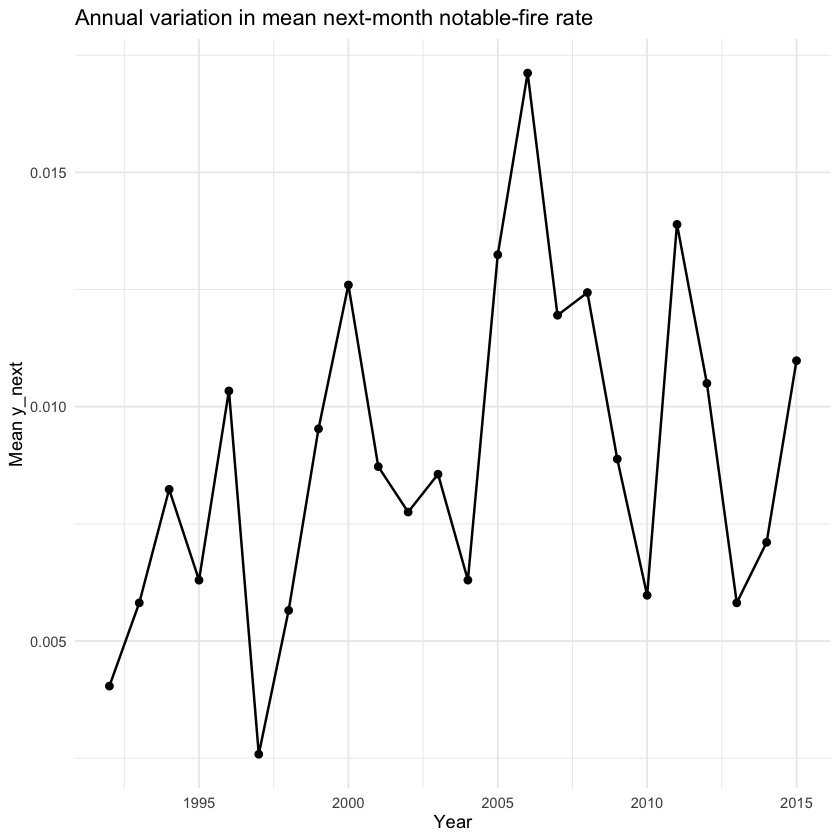

In [45]:
eda_year <- panel %>%
  group_by(year) %>%
  summarise(
    next_fire_rate = mean(y_next),
    .groups = "drop"
  )

ggplot(eda_year, aes(x = year, y = next_fire_rate)) +
  geom_line(linewidth = 0.7, color = "black") +
  geom_point(size = 1.8, color = "black") +
  labs(
    title = "Annual variation in mean next-month notable-fire rate",
    x = "Year",
    y = "Mean y_next"
  ) +
  theme_minimal()

### Interpretation

The annual series shows noticeable year-to-year fluctuation in average next-month wildfire risk. The rate does not remain constant over the study period, which suggests that broad temporal changes may also matter in prediction. Including `year` as a baseline feature may help account for long-run shifts not captured by seasonal or spatial variables alone.

## Summary of EDA findings

Overall, the EDA shows that next-month notable-fire risk varies across **space**, **season**, **recent fire history**, and **year**. Some grid cells consistently have higher average risk than others, indicating meaningful geographic heterogeneity. The monthly pattern shows clear seasonality, with higher risk in late spring and summer. In addition, grid cells with more fire activity in the previous 12 months have substantially higher next-month risk. 

# 3. Modeling

This section compares two predictive models for next-month notable-fire occurrence.

We fit the following models:

1. **Baseline model:** logistic regression  
2. **Model of choice:** gradient-boosted trees (XGBoost)

The baseline logistic model provides a transparent benchmark for binary prediction. It is useful because the coefficients can be interpreted directly in terms of how each predictor affects the log-odds of a notable fire in the following month.

XGBoost is included as a more flexible alternative. Because wildfire risk may depend on nonlinear effects and interactions among geography, seasonality, and recent fire history, a tree-based boosting model may capture predictive structure that a linear model cannot.

In [65]:
model_df <- panel %>%
  transmute(
    y_next = factor(y_next, levels = c(0, 1)),
    lat_bin = lat_bin,
    lon_bin = lon_bin,
    state = as.factor(state),
    month_sin = month_sin,
    month_cos = month_cos,
    year = year,
    n_fires = n_fires,
    fire_lag12 = fire_lag12,
    fire_roll3 = fire_roll3,
    fire_roll12 = fire_roll12,
    size_roll3 = size_roll3,
    size_roll12 = size_roll12
  )

glimpse(model_df)

Rows: 147,060
Columns: 13
$ y_next      <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0~
$ lat_bin     <dbl> 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17~
$ lon_bin     <dbl> -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67~
$ state       <fct> PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR~
$ month_sin   <dbl> 5.000000e-01, 8.660254e-01, 1.000000e+00, 8.660254e-01, 5.~
$ month_cos   <dbl> 8.660254e-01, 5.000000e-01, 6.123234e-17, -5.000000e-01, -~
$ year        <int> 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992~
$ n_fires     <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0~
$ fire_lag12  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0~
$ fire_roll3  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0~
$ fire_roll12 <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0~
$ size_roll3  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0~
$ size_roll12 

The baseline model is written as a logistic regression with spatial, seasonal, and fire-history terms:

$$
\text{logit}(p_{g,t}) = \beta_0 + \text{spatial terms} + \text{seasonal terms} + \text{fire-history terms}.
$$
This specification is useful as a benchmark because it provides an interpretable reference point for model comparison. The boosted-tree model is then used to test whether allowing more flexible nonlinear patterns improves predictive performance.

# 4. Model Fitting and Validation

Model evaluation follows a **time-aware expanding-window validation** design. For each fold, training uses all years up to year \(t\), and validation is performed on year \(t+1\). This preserves temporal order and avoids leakage from future observations.

Because the outcome is highly imbalanced, we use **AUC** as the primary evaluation metric for both models.

The expanding window method is suitable for predicting future temperatures because it preserves the temporal order of the data. These models are trained on data from the previous year and tested on the following year in each fold to avoid utilizing any information about the future to estimate future results. This reduces temporal bias and more closely resembles the real-world forecasting situation, where wildfire risk would only be assessed using the historical data that was available at the time.

In [96]:
set.seed(141)
years_sorted <- sort(unique(model_df$year))
min_train_years <- 3

feat_formula <- y_next ~ lat_bin * lon_bin + state +
  month_cos + month_sin + year +
  n_fires + fire_lag12 + fire_roll3 + fire_roll12 +
  size_roll3 + size_roll12

fold_results <- tibble(
  train_end_year = years_sorted[min_train_years:(length(years_sorted) - 2)],
  valid_year = years_sorted[(min_train_years + 1):(length(years_sorted) - 1)]
) %>%
  mutate(
    auc_glm = purrr::map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
      train <- model_df %>% filter(year <= tr_end)
      valid <- model_df %>% filter(year == va_year)

      fit <- suppressWarnings(
        glm(feat_formula, data = train, family = binomial)
      )

      p_hat <- predict(fit, newdata = valid, type = "response")

      as.numeric(
        pROC::auc(
          pROC::roc(response = valid$y_next, predictor = p_hat, quiet = TRUE)
        )
      )
    }),

    auc_xgb = purrr::map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
      train <- model_df %>% filter(year <= tr_end)
      valid <- model_df %>% filter(year == va_year)

      new_data <- bind_rows(train, valid) %>%
        mutate(state = factor(state, levels = levels(model_df$state)))

      x_all <- model.matrix(feat_formula, data = new_data)[, -1, drop = FALSE]
      x_train <- x_all[seq_len(nrow(train)), , drop = FALSE]
      x_valid <- x_all[(nrow(train) + 1):nrow(new_data), , drop = FALSE]

      y_train <- as.numeric(train$y_next) - 1
      y_valid <- as.numeric(valid$y_next) - 1

      scale_pos_weight <- sum(y_train == 0) / sum(y_train == 1)

      dtrain <- xgboost::xgb.DMatrix(data = x_train, label = y_train)
      dvalid <- xgboost::xgb.DMatrix(data = x_valid, label = y_valid)

      xgb_model <- xgboost::xgb.train(
        params = list(
          objective = "binary:logistic",
          eval_metric = "auc",
          booster = "gbtree",
          eta = 0.05,
          max_depth = 3,
          min_child_weight = 5,
          subsample = 0.7,
          colsample_bytree = 0.7,
          gamma = 1,
          lambda = 1,
          alpha = 1,
          scale_pos_weight = scale_pos_weight,
          nthread = 8
        ),
        data = dtrain,
        evals = list(train = dtrain, valid = dvalid),
        nrounds = 1000,
        early_stopping_rounds = 50,
        verbose = 0
      )

      p_hat_xgb <- predict(xgb_model, dvalid)

      as.numeric(
        pROC::auc(
          pROC::roc(response = valid$y_next, predictor = p_hat_xgb, quiet = TRUE)
        )
      )
    })
  )

fold_results

train_end_year,valid_year,auc_glm,auc_xgb
<int>,<int>,<dbl>,<dbl>
1994,1995,0.6757262,0.7418020
1995,1996,0.7232376,0.8104066
1996,1997,0.7932319,0.8313836
1997,1998,0.7585188,0.8174784
1998,1999,0.6679481,0.7135212
1999,2000,0.7261246,0.7794354
2000,2001,0.7575094,0.8359235
2001,2002,0.7296244,0.7977668
2002,2003,0.7293333,0.8064140


The fold-by-fold AUC values summarize model performance under a realistic forecasting setup. If one model consistently attains higher AUC across validation years, that model can be considered more effective for ranking future wildfire risk.

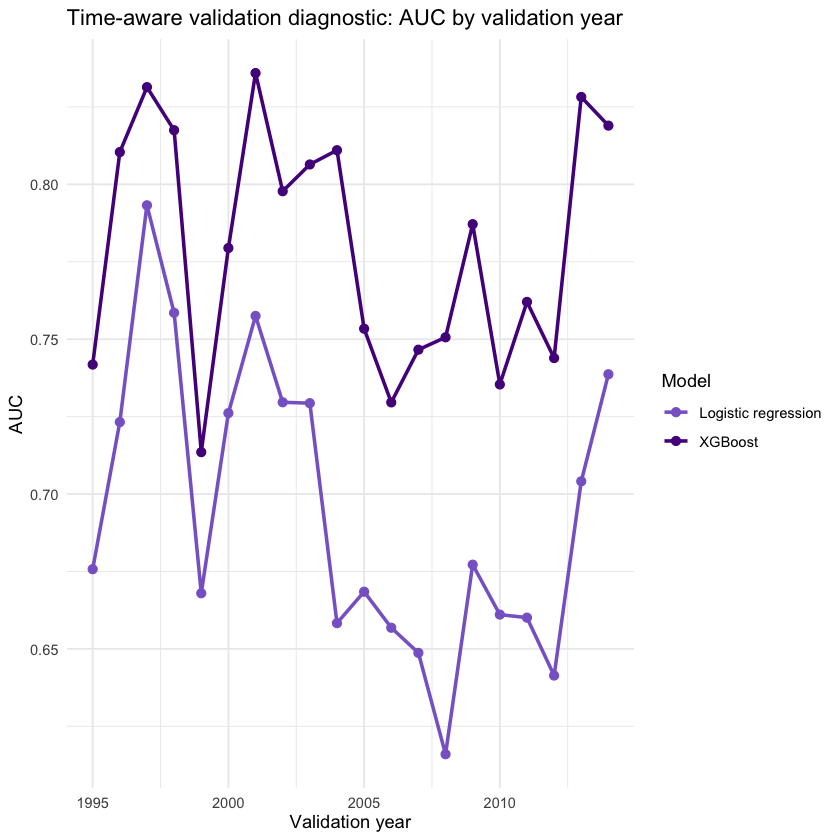

In [104]:
fold_plot <- fold_results %>%
  pivot_longer(
    cols = c(auc_glm, auc_xgb),
    names_to = "model",
    values_to = "auc"
  )

ggplot(fold_plot, aes(x = valid_year, y = auc, color = model)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2.2) +
  scale_color_manual(
    values = c(
      "auc_glm" = "mediumpurple3",
      "auc_xgb" = "purple4"
    ),
    labels = c(
      "auc_glm" = "Logistic regression",
      "auc_xgb" = "XGBoost"
    )
  ) +
  labs(
    title = "Time-aware validation diagnostic: AUC by validation year",
    x = "Validation year",
    y = "AUC",
    color = "Model"
  ) +
  theme_minimal()

The diagnostic plot compares the two models across validation folds. The year-to-year variation reflects differences in wildfire conditions over time, while the relative position of the two curves indicates which model provides stronger discrimination in each fold.

In [105]:
auc_summary <- fold_results %>%
  summarise(
    mean_auc_glm = mean(auc_glm),
    mean_auc_xgb = mean(auc_xgb),
    relative_gain_pct = 100 * (mean_auc_xgb / mean_auc_glm - 1)
  )

auc_summary

mean_auc_glm,mean_auc_xgb,relative_gain_pct
<dbl>,<dbl>,<dbl>
0.6946006,0.7800461,12.30138


In [106]:
cat(
  "Overall, XGBoost outperforms logistic regression in AUC by ",
  round(auc_summary$relative_gain_pct, 2),
  "%.",
  sep = ""
)

Overall, XGBoost outperforms logistic regression in AUC by 12.3%.

Overall, the boosted-tree model achieves higher AUC than logistic regression on average, indicating that nonlinear effects and feature interactions improve predictive performance. This result is consistent with the earlier EDA, which suggested that wildfire risk varies across location, season, and recent fire history in ways that may not be fully captured by a simple linear model.

In summary, the time-aware validation results show that XGBoost provides stronger predictive discrimination than the baseline logistic regression model across most validation years. The expanding-window design ensures that this comparison respects temporal order, making the evaluation more appropriate for a forecasting problem.

### Baseline model interpretation

Beyond predictive performance, it is also useful to examine which variables are most strongly associated with next-month notable-fire occurrence in the baseline logistic regression model. To do this, we fit the logistic model on the full dataset and summarize the most influential non-state predictors using estimated coefficients, odds ratios, and p-values.

This step is descriptive rather than causal. Its purpose is to identify which feature groups appear most important in the linear benchmark model.

In [107]:
glm_full <- glm(
  y_next ~ lat_bin + lon_bin + state +
    month_cos + month_sin + year +
    n_fires + fire_lag12 + fire_roll3 + fire_roll12 +
    size_roll3 + size_roll12,
  data = panel,
  family = binomial
)

coef_table <- broom::tidy(glm_full) %>%
  filter(term != "(Intercept)") %>%
  filter(!grepl("^state", term)) %>%
  mutate(
    odds_ratio = exp(estimate),
    abs_stat = abs(statistic),
    variable = dplyr::recode(
      term,
      month_cos = "Month cosine term",
      month_sin = "Month sine term",
      year = "Year",
      n_fires = "Current-month fire count",
      fire_lag12 = "Fire count 12 months earlier",
      fire_roll3 = "Rolling 3-month fire count",
      fire_roll12 = "Rolling 12-month fire count",
      size_roll3 = "Rolling 3-month fire size",
      size_roll12 = "Rolling 12-month fire size",
      lat_bin = "Latitude bin",
      lon_bin = "Longitude bin"
    )
  ) %>%
  arrange(desc(abs_stat)) %>%
  select(variable, estimate, odds_ratio, p.value) %>%
  slice_head(n = 10)

coef_table

variable,estimate,odds_ratio,p.value
<chr>,<dbl>,<dbl>,<dbl>
Month cosine term,-8.499048e-01,0.4274556,5.935871e-78
Month sine term,2.665651e-01,1.3054726,1.574714e-10
Current-month fire count,9.949882e-01,2.7046925,1.525224e-08
Year,1.783084e-02,1.0179908,1.334807e-05
Rolling 12-month fire count,2.613032e-01,1.2986213,8.847741e-05
Fire count 12 months earlier,5.399143e-01,1.7158598,4.291813e-04
Rolling 3-month fire size,-2.998050e-05,0.9999700,1.310396e-01
Latitude bin,-2.354249e-02,0.9767325,1.687994e-01
Rolling 12-month fire size,3.362462e-06,1.0000034,3.571809e-01


The baseline logistic regression suggests that temporal features and wildfire-history variables are among the most influential predictors. In particular, current-month fire count, fire count from 12 months earlier, and rolling 12-month fire activity all show positive estimated effects, indicating that recent and recurring wildfire activity is associated with higher next-month risk.

These results are broadly consistent with the exploratory analysis. The EDA showed both strong seasonality and persistence in fire occurrence, and the coefficient table suggests that the baseline linear model captures part of that structure.

# 5. Summary

**Data preprocessing and feature engineering**

· The wildfire incident records were organized into a grid-month panel dataset, where each spatial grid cell is represented for every observed month. Because notable fires occur relatively infrequently, the next-month prediction target is highly imbalanced.

· To reflect a realistic forecasting scenario, time-aware feature engineering was applied. Lagged variables and rolling summaries of past wildfire activity were constructed so that each predictor uses only historical information, preventing temporal leakage.

· Geographic and categorical variables such as state and spatial grid bins were encoded appropriately, while seasonal patterns were represented using cyclical features (sine and cosine transformations of month).

**Key insights from exploratory data analysis**

· The exploratory analysis revealed strong spatial heterogeneity in wildfire risk. Some grid cells consistently show higher wildfire activity, suggesting that geographic location plays an important role in determining baseline wildfire probability.

· Clear seasonal patterns were also observed, with wildfire activity varying significantly across months. This supports the inclusion of cyclical seasonal predictors in the modeling process.

· In addition, recent wildfire activity appears informative for prediction, indicating that wildfire occurrence may exhibit short-term persistence over time.

These observations align with general discussions of wildfire dynamics reported in environmental research (DOI Wildfire Prevention Blog).

**Modeling takeaway**

· Model evaluation was conducted using time-aware expanding-window cross-validation, ensuring that models were trained only on past observations and evaluated on future periods. This approach better reflects real forecasting conditions and avoids temporal leakage.

Across validation folds, the XGBoost gradient-boosted tree model consistently achieved higher AUC values than the baseline logistic regression model.

· This improvement suggests that nonlinear relationships and interactions among geographic location, seasonal patterns, and recent fire activity contribute meaningful predictive power beyond what can be captured by a linear model.

**Limitations and future work**

· This analysis focuses only on notable wildfire events, meaning smaller fires are not included in the modeling framework.

· The study uses a relatively coarse 1° × 1° spatial grid, which limits spatial precision.

· In addition, the dataset does not include several important predictors such as weather conditions, drought indicators, vegetation, and human activity, which are known to influence wildfire risk.

Future work could incorporate richer environmental variables and finer spatial resolution to further improve wildfire risk prediction.

### **Reference**

https://www.doi.gov/blog/10-tips-prevent-wildfires